**Dataset:**
personality type data (Lab 2 - Personality Profile Type.csv)

**Objective:**
classify Personality type as one of the following **using RNNs**. <br>
['INFJ', 'ENTP', 'INTP', 'INTJ', 'ENTJ', 'ENFJ', 'INFP', 'ENFP',
       'ISFP', 'ISTP', 'ISFJ', 'ISTJ', 'ESTP', 'ESFP', 'ESTJ', 'ESFJ']

**Evaluation metric:**
Precision

### Import used libraries

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 500)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [4]:
df = pd.read_csv(r"/kaggle/input/datasets/ahmedfayad/personallity-data/Lab 3 - Personality Profile Type.csv")
df.head(10)

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments https://www.youtube.com/watch?v=iz7lE1g4XM4 sportscenter not top ten plays https://www.youtube.com/watch?v=uCdfze1etec pranks|||What has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8 http://www.youtube.com/watch?v=u8ejam5DP3E On repeat for most of today.|||May the PerC Experience immerse you.|||The last ...
1,ENTP,'I'm finding the lack of me in these posts very alarming.|||Sex can be boring if it's in the same position often. For example me and my girlfriend are currently in an environment where we have to creatively use cowgirl and missionary. There isn't enough...|||Giving new meaning to 'Game' theory.|||Hello *ENTP Grin* That's all it takes. Than we converse and they do most of the flirting while I acknowledge their presence and return their words with smooth wordplay and more cheeky grins.|||This...
2,INTP,"'Good one _____ https://www.youtube.com/watch?v=fHiGbolFFGw|||Of course, to which I say I know; that's my blessing and my curse.|||Does being absolutely positive that you and your best friend could be an amazing couple count? If so, than yes. Or it's more I could be madly in love in case I reconciled my feelings (which at...|||No, I didn't; thank you for a link!|||So-called Ti-Si loop (and it can stem from any current topic/obsession) can be deadly. It's like when you're stuck in your o..."
3,INTJ,"'Dear INTP, I enjoyed our conversation the other day. Esoteric gabbing about the nature of the universe and the idea that every rule and social code being arbitrary constructs created...|||Dear ENTJ sub, Long time no see. Sincerely, Alpha|||None of them. All other types hurt in deep existential ways that I want no part of.|||Probably a sliding scale that depends on individual preferences, like everything in humanity.|||Draco Malfoy also. I'd say he's either 358 or 368.|||I'm either 358..."
4,ENTJ,'You're fired.|||That's another silly misconception. That approaching is logically is going to be the key to unlocking whatever it is you think you are entitled to. Nobody wants to be approached with BS...|||But guys... he REALLY wants to go on a super-duper-long-ass vacation. C'mon guys. His boss just doesn't listen or get it. He even approached him logically and everything.|||Never mind. Just go on permanent vacation.|||Two months? I wouldn't be crazy about the idea. If you are really hi...
5,INTJ,"'18/37 @.@|||Science is not perfect. No scientist claims that it is, or that scientific information will not be revised as we discover new things. Rational thinking has been very useful to our society....|||INFP- Edgar Allen Poe was an INFP and he's in your siggy.|||People see the obvious Fi and are quick to put her as INFP. I agree that she has no Ne. I see her as an ISFP. Compare her to Haku (definite INFP). She is flat through most of Naruto.. but I don't...|||Lets get this party star..."
6,INFJ,"'No, I can't draw on my own nails (haha). Those were done by professionals on my nails. And yes, those are all gel. You mean those you posted were done by yourself on your own nails? Awesome!|||Probably the Electronic Screen Syndrome. With the advent of technology and social media, we all suffer from overstimulation on a daily basis. I'm guilty as well. In the past, I can be happy just...|||I love nail arts too! These are some of mine: 718282 718290 718298 718306 718314|||This is the first..."
7,INTJ,"'I tend to build up a collection of things on my desktop that i use frequently and then move them into a folder called 'Everything' from there it get sorted into type and sub type|||i ike to collect odd objects, even at work...a lot of people would call it junk but i like to collect it. Old unused software? ill take that off your hands :) i have a bunch of old adobe...|||i think its quite normal, i tend to only see my friends in real life every c

### Data splitting

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = df.drop("type",axis = 1)
y = df["type"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

### EDA on training data

- check NaNs

In [8]:
X_train.isna().sum()

posts    0
dtype: int64

- check duplicates

In [9]:
X_train.duplicated().sum()

np.int64(0)

- show a representative sample of data texts to find out required preprocessing steps

In [10]:
df[df["type"] == "INFJ"]

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments https://www.youtube.com/watch?v=iz7lE1g4XM4 sportscenter not top ten plays https://www.youtube.com/watch?v=uCdfze1etec pranks|||What has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8 http://www.youtube.com/watch?v=u8ejam5DP3E On repeat for most of today.|||May the PerC Experience immerse you.|||The last ...
6,INFJ,"'No, I can't draw on my own nails (haha). Those were done by professionals on my nails. And yes, those are all gel. You mean those you posted were done by yourself on your own nails? Awesome!|||Probably the Electronic Screen Syndrome. With the advent of technology and social media, we all suffer from overstimulation on a daily basis. I'm guilty as well. In the past, I can be happy just...|||I love nail arts too! These are some of mine: 718282 718290 718298 718306 718314|||This is the first..."
8,INFJ,"I'm not sure, that's a good question. The distinction between the two is so dependant on perception. To quote Robb Flynn, ''The hate you feel is nothing more, than love you feel to win this war.''|||Good question! It's tough to say for sure but I loved Winona Ryder as Lydia in Beetlejuice... http://i63.photobucket.com/albums/h158/trinsghost/Misc-Images/2921aa070866f20450f8e1160b1e5d41.jpg|||https://www.youtube.com/watch?v=r5If816MhoU|||https://www.youtube.com/watch?v=Q-sQklvpDhA|||I've been..."
10,INFJ,"'One time my parents were fighting over my dad's affair and my dad pushed my mom. The fall broke her finger. She's pointed a gun at him and made him get on his knees and beg for his life. She's...|||I'm gonna talk about what a piece of shit my dad is now. He's an alcoholic and he has some kind of serious mental problem when it comes to complying with the IRS. (In his words, Laws don't apply...|||OMG...at the women's center I lived at, run by a Catholic charity, the fat bully program manage..."
12,INFJ,"'Joe santagato - ENTP|||ENFJ or ENTP? I'm not too sure of his type yet|||You know you're not INFJ if heavy Fi doesn't make you want to violently bang your head against a wall lol You know you're not INFJ if you don't naturally and helplessly just feel compassion for...|||Yeah, according to the book she's a IxTP. I could relate to the movie character a lot. Coming into a world where Se is so prominent and becoming incredibly self conscious, feeling like the weakest...|||Tris - INFJ (most ..."
...,...,...
8645,INFJ,"'I play cello, and I'm also a classically trained soprano. I can play piano, but it's mostly functional more so than anything else, haha! I'd say I'm most adept at voice - it's what I majored in at...|||What state do you live in, Heyoka? I looked up the requirements for Texas (to see an example of a state's requirements), and it doesn't seem like it's too difficult, thankfully. As an immediate...|||Ambrosia The main form I encounter in my life is medical woo, haha. I have lupus with organ in..."
8650,INFJ,"'I think the real question is whether INFJs can be NEAT. Dominant function Ni, focused on the internal world. Main function to do with organization = Si = most far removed function of INFJ....|||I don't know if it's an INFJ thing but I'm always pretty calm in an emergency. If i know how to solve it then i'll 'save the day' If not then i'll find the person who can and 'be the perfect...|||helllloooo. I know the feel of being an extraverted introvert so don't worry, you are not alone. Welcome..."
8655,INFJ,"'I find that poster and your facial expression, along with the fact that you are INTP, so ironic. Lmao. 10/10 points|||I can definitely see how this happens. I used to do this too and jump to false conclusions. But I think once the function and the individual mature and develop, this becomes less of an issue. This...|||Gonna have to say ESFJs...|||Reading through your posts coupled with people saying you shoul

In [11]:
df[df["type"] == "ENTP"]

,type,posts
1,ENTP,'I'm finding the lack of me in these posts very alarming.|||Sex can be boring if it's in the same position often. For example me and my girlfriend are currently in an environment where we have to creatively use cowgirl and missionary. There isn't enough...|||Giving new meaning to 'Game' theory.|||Hello *ENTP Grin* That's all it takes. Than we converse and they do most of the flirting while I acknowledge their presence and return their words with smooth wordplay and more cheeky grins.|||This...
64,ENTP,"'I believed in God all my life up until about a year ago. My mother was a very strong believer in God and encouraged me and my brothers to be the same way. She didn't force it down our throats or...|||I lurk everywhere to be honest.|||I had a bunny. Named Lola. After the Loony Toon. She shitted on me once.|||I'm only 18, really.|||Frequently.|||I'm really a 54 year old man.|||I was thinking this. Anyway, my brother and a close friend of mine are ENFPs. Both are the shit. And I could definit..."
82,ENTP,"'Good stuff. I used cpa excel to study and basically tried to learn a little bit about every sub topic - you can't get too bogged down in the details...if you catch yourself getting bogged down, look...|||I'm not too familiar with bands, but it looks like an LLC is a good structure. If I was going to pay the fees to set one up though, I'd just go ahead and create an S-corp as that is more formal and...|||I think you guys all have a very traditional view of what the game entails. 40 messag..."
90,ENTP,"'I know an ENTJ and it's everything I wanted to be. So full of purpose and the drive to execute in the best quality, but intimidating. Some INTJs I met are pretty cool, you can leave them be and still...|||Whilst engaging in a conversation, you've already anticipated the response two words in and your mind is already drifting far ahead. If it's not according to your prediction, you multitask anyway.|||Yup.|||yeah I know more than one language. By accident, because I'm born in a place that sp..."
110,ENTP,"'I'm dating a guy that I'm about 95% sure is an INFJ, and the mushy stuff doesn't bother me. Mostly because his mushy comes in the form of physical affection vs sonnets or pet names. However, once...|||Now this makes me laugh! I recently have come to terms with the fact that I might possibly have sex appeal and I'm not sure how comfortable I am with that. When guys I think are super hot tell me...|||I feel like some people don't always see the potential in a particular relationship that ..."
...,...,...
8639,ENTP,"'Do bare with me. I become bored, quickly and often. Which is why I've ignored this site long enough to the point of forget. Like a radio station being listened to too much, sometimes you just...|||I never studied. I was a pretty quick learner and remembered things easily. But whenever I was in doubt, whether it be before a test or not, I would skim read an entire chapter (that I had just...|||I can have a good sense of time when I WANT to. As in, if I'm busy and need to coordinate my d..."
8643,ENTP,"'Primeval I know a thing or too about C++ xD|||garee yeah. We grew up learning filipino and english. English is sometimes a determinant of a social class. It's just that I'm more interested in a foreign language.|||WamphyriThrall currently checking the sites you offered. I'll get back on you as soon as I get my results. Imo, I think for ENTPs or someone who thinks like me, a class would be a compulsory. I'm...|||WamphyriThrall I'm now thinking what language will have the biggest importance i..."
8661,ENTP,"'**haven't logged in and read posts for over 6 months so am catching up on everything. I am a black belt in Shotokan and am doing Muay Thai now. 1) for learning more sparring. 2) travel...|||To the person trying to enter the shop via the automatic door... Ummm that isn't the automatic door, that is just a large glass window... The door is around the corner...|||I sit centred middle or near the front but 

In [12]:
df[df["type"]=="INTJ"]

,type,posts
3,INTJ,"'Dear INTP, I enjoyed our conversation the other day. Esoteric gabbing about the nature of the universe and the idea that every rule and social code being arbitrary constructs created...|||Dear ENTJ sub, Long time no see. Sincerely, Alpha|||None of them. All other types hurt in deep existential ways that I want no part of.|||Probably a sliding scale that depends on individual preferences, like everything in humanity.|||Draco Malfoy also. I'd say he's either 358 or 368.|||I'm either 358..."
5,INTJ,"'18/37 @.@|||Science is not perfect. No scientist claims that it is, or that scientific information will not be revised as we discover new things. Rational thinking has been very useful to our society....|||INFP- Edgar Allen Poe was an INFP and he's in your siggy.|||People see the obvious Fi and are quick to put her as INFP. I agree that she has no Ne. I see her as an ISFP. Compare her to Haku (definite INFP). She is flat through most of Naruto.. but I don't...|||Lets get this party star..."
7,INTJ,"'I tend to build up a collection of things on my desktop that i use frequently and then move them into a folder called 'Everything' from there it get sorted into type and sub type|||i ike to collect odd objects, even at work...a lot of people would call it junk but i like to collect it. Old unused software? ill take that off your hands :) i have a bunch of old adobe...|||i think its quite normal, i tend to only see my friends in real life every couple of months, as said earlier some people..."
13,INTJ,"'Fair enough, if that's how you want to look at it. Like I stated before, they were incredibly naive in their comments... However, they think those are things that would help us because those are the...|||For myself, MBTI serves as a source of self reflection and an opportunity to better myself. Therefore, when an opportunity to gain insight on what are things that I may be able to improve upon, I...|||I think this article is a lot more helpful if one views it as 22 people share one thing th..."
36,INTJ,"'Poker face for sure, accompanied by some sarcasm probably! But inside I'm running a pretty vivid list of pros and cons starting with asking myself 'do I like them back'? I probably know the answer...|||1. Babies are illogical. 2. Nobody is despised who can manage a crocodile. 3. Illogical persons are despised. Therefore, babies cannot manage crocodiles. 1. No interesting poems are unpopular...|||Well yeah, zero sounds legitimate, but I've found for myself that there are other life forms be..."
...,...,...
8637,INTJ,'Screams INFJ for whatever that is worth -- for many of the reasons listed above by others posters.|||No idea hah! Been on a long project away from the forums and civilization really. I have all intents and purposes given up on trying to figure my type out. The help you provided was very welcome...|||Agreed. Se without a doubt is the inferior. If you could describe the issue in as much depth or detail as possible that would be helpful. Still interested in that other topic to about what.....
8657,INTJ,"Social 1) Generally, I positively associate with the idea of being a part of something larger than myself. Though I may find it either overwhelming, because of my astute awareness of what lies...|||Type 5: Cerebral detachment from the moment. Invisible shell or carapace keeps humanity at arms length. Almost not really there, a kind of observing spectre.|||I've been trying to think of a one word descriptor for my tritype archetype (145), without success. I've come up with 'truth' for the 46..."
8662,INTJ,"'I can't say I have any one specific belief. I mean why should I limit myself to one simple code that couldn't possibly answer every question when I can learn of so many and see so many new ways of...|||When you do something right, no one knows you've done anything at all. That's my motto. Though somedays I can revel a little too much in the evil stereotype.|||If I really put my brain into it I can do it, but af

### How many Posts in X instance

In [14]:
len(df["posts"][10].split("|||"))

50

## First of all let's dicuss data
  - The classes of data indicate on 4 charcters first I/E `Introvert`/`Extrovet` - N/T `Intution`/`Sensing` - T/H `Thinking`/`Feeling` - `Judjing`/`Perciving`
  - Data it self contain many links so we need to filter this link or see how to handle it
  - The data cintain charcters like *** it seem that data from Blogs or sochial media or whatever
  - the posts seperated |||
  - some posts contain Charcter of post owner and not nessacery owner
  - The data contain charcters like @@
  - The data contain numerical value
  - The data contain Spacific Upper case in meaning
  - This data is a part of conversation
  - The data need NER `Named Entitty Recognition` there is people names mantioned
  - The data contain // Charcters
  - we need to make convert using contarction library
  - the data contain `?` but we well see how to handle it

- check dataset balancing

<Axes: xlabel='type', ylabel='count'>

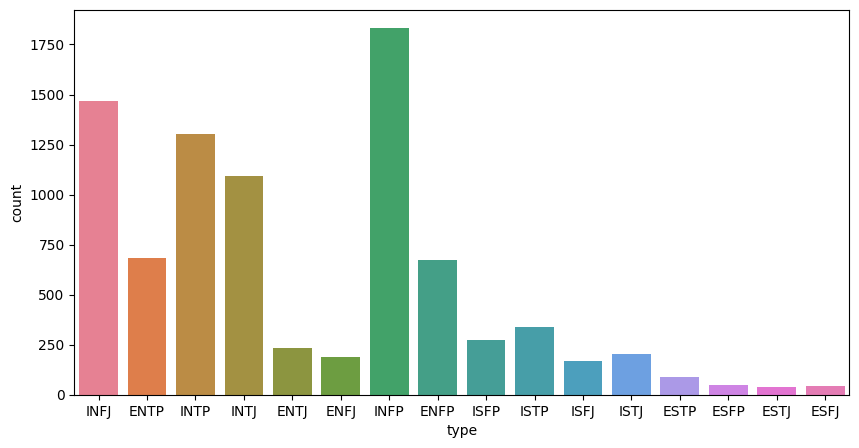

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(df,x = "type",hue = "type")

- Cleaning and Preprocessing are:
    - 1. Remove Links , ||| , @@@ , ** ,||| deal with it a sepertor 
    - 2. remove numeric value
    - 3. make Lower case for data
    - 4. use Ner at data to handle name
    - 5. apply contarction and reomve punc
    - 6. encode data
    - 7. train model

### To be discussed Inshallah at Lab dicuession

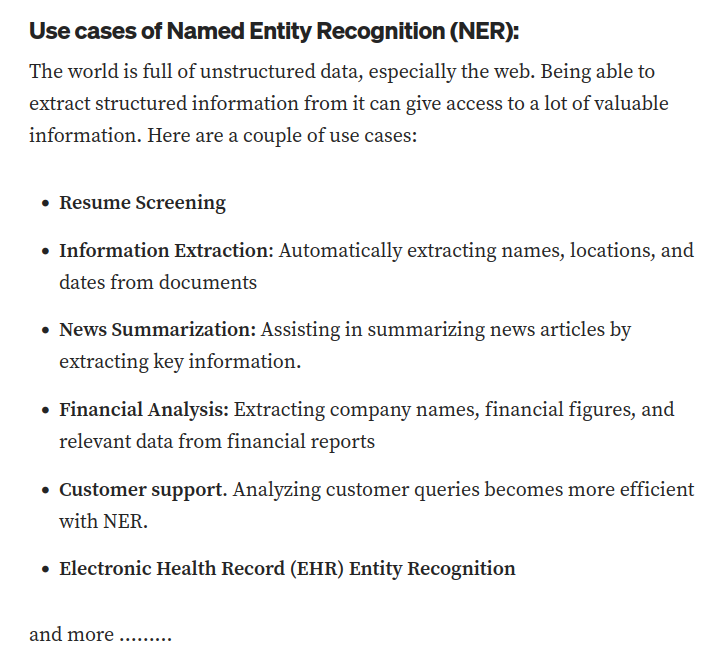

### Read on medium `https://medium.com/thedeephub/nlp-text-preprocessing-named-entity-recognition-ner-part-5-1-52ef13a9f2e0`

### From Chatgpt also

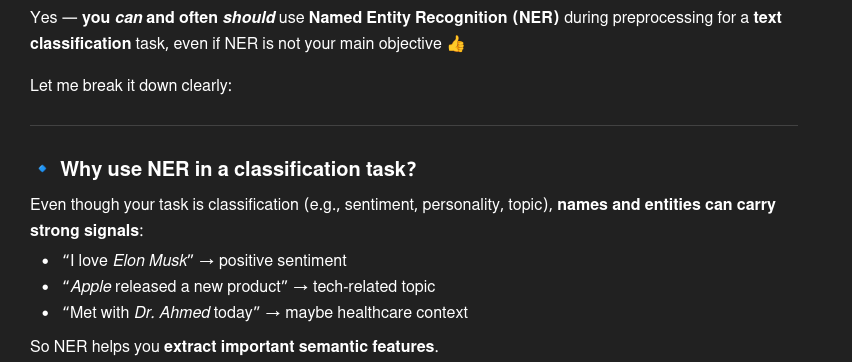

### Cleaning and Preprocessing

In [16]:
!pip install contractions

In [17]:
import contractions
import re
import string

In [18]:
import spacy
import requests
from bs4 import BeautifulSoup
nlp = spacy.load("en_core_web_sm")
pd.set_option("display.max_rows", 200)

In [19]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [20]:
def clean_text_keep_separator(text: str):
    # 1. remove links
    text = re.sub(r'http\S+', '', text)
    # 2. remove special patterns except |||
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'\*\*\*', '', text)
    text = re.sub(r'//', '', text)
    # 3. remove numbers
    text = re.sub(r'\d+', '', text)
    # 4. fix contractions
    text = contractions.fix(text)
    # 5. lowercase
    text = text.lower()
    # 6. remove punctuation except |||
    # Replace ||| temporarily with placeholder
    text = text.replace("|||", "SPECIALSEP")
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Restore |||
    text = text.replace("SPECIALSEP", "|||")
    # 7. tokenize, lemmatize, and rejoin
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    text = ' '.join(lemmatized_words)
    return text

### Make inspect to function triggring in random texts in dataset

### See random sample from data set and our function behaviour

In [21]:
import random

random_text_index = random.randint(0, len(X_train) - 1)
random_text = X_train.iloc[random_text_index]

print(clean_text_keep_separator(random_text[0]))

/tmp/ipykernel_297/2330561185.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(clean_text_keep_separator(random_text[0]))


animated music video share your favorite or just any cool amv kitteh kitteh|||i do not know if anyone else experience this but i have a recurring dream it usually start off with waking up and then sneaking out the door or out a window making sure that no one find out i||| i think you are trying to understand yourself better which can be a good thing but also a bad thing i am sure you know what i mean i also think you are very self absorbed and spend way|||fairies when he decided to threaten you and when he decided to slash your tire he knew what he could get himself into this is an effect that he caused do not feel bad you did not do anything|||small will awww but i wa so curious but ok no problem kitteh|||small will i would say entjintj it depends if you prefer to be around people or by yourself the following question are in order to determine your enneagram are you confrontational do you|||i am blue and environmental tan kitteh||| try looking into these mental disorder borderline per

### Check Seperation preprocessing

In [22]:
len(clean_text_keep_separator(random_text[0]).split("|||"))

/tmp/ipykernel_297/411513332.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  len(clean_text_keep_separator(random_text[0]).split("|||"))


48

### Finally apply our wounderful function on our dataset

In [23]:
from tqdm import tqdm
tqdm.pandas()

X_train = X_train["posts"].progress_apply(clean_text_keep_separator)

100%|██████████| 6940/6940 [00:35<00:00, 195.99it/s]


In [24]:
X_train

8331    this is actually exactly what i expected laughing introversion ||||||||| ||||||||||||||| extroversion ||||||||||||||| ||||||||| intuitive |||||||||||||||||||||now that you have had time to chill out here come the boundless insanity and awesomeness p just noticed the weird tenseperspective of this sentence it is being spoken by the universe to me|||i am going to post before i actually read the entire thread name a famous person you do not like mel gibson what wa the last thing you bought groc...
1290    nope not now not ever i am too busy with work cause and adrenalinerush activity and i will do anything to make sure no one can keep up freedom forever||||||i did some thinking today and i decided to arrive at this conclusion i never really understood negative feeling in the past so i tried to repress them hoping that they would go away and i would|||how often do you guy find yourself miscommunicating with others or using your own lingo when talking with others i remember djarende

In [25]:
from tqdm import tqdm
tqdm.pandas()

X_test = X_test["posts"].astype(str).progress_apply(clean_text_keep_separator)

100%|██████████| 1735/1735 [00:08<00:00, 196.35it/s]


**You  are doing Great so far!**

### Modelling

### Start Import nesscey Library

In [26]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import os
import requests
import zipfile
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import precision_score, f1_score

### Determine Config of Hyper Parameter

In [27]:
CONFIG = {
    "glove_dim":    100,        # GloVe vector size
    "lstm_hidden":  128,        # word-level LSTM hidden size → output = 1 vector per post
    "fc_hidden":    256,        # vanilla NN hidden size
    "dropout":      0.3,
    "num_posts":    50,
    "max_words":    100,        # pad/truncate each post to this many words
    "batch_size":   32,
    "epochs":       20,
    "lr":           1e-3,
    "aggregation":  "mean",     # "mean" | "attention"
    "glove_path":   "glove.6B.100d.txt",
    "device":       "cuda" if torch.cuda.is_available() else "cpu",
}

### Basic Approach using LSTMs

In [28]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from gensim.models import Word2Vec
import torch.nn.functional as F

# ─────────────────────────────────────────────
# 1. Gensim Word2Vec Training & Feature Extraction
# ─────────────────────────────────────────────
def train_gensim_w2v(X_train, vector_size=100, window=5, min_count=1):
    print("Training Gensim Word2Vec model on training data...")
    # Split each user's string into separate posts, then into words
    corpus = []
    for user_posts in X_train:
        posts = user_posts.split('|||')
        for post in posts:
            corpus.append(post.split())
    
    # Train the Word2Vec model
    w2v_model = Word2Vec(sentences=corpus, vector_size=vector_size, window=window, min_count=min_count, workers=4)
    return w2v_model

def get_user_embeddings(X, w2v_model, num_posts=50, vector_size=100):
    """
    Computes the average word embedding for each of the 50 posts per user.
    Outputs a tensor of shape (num_users, 50, vector_size).
    """
    print(f"Creating average embeddings for {len(X)} instances...")
    X_features = np.zeros((len(X), num_posts, vector_size), dtype=np.float32)
    
    for i, user_string in enumerate(X):
        posts = user_string.split('|||')
        posts = posts[:num_posts] # Ensure strictly 50 posts
        
        for j, post in enumerate(posts):
            words = post.split()
            # Retrieve embeddings only for words that exist in gensim vocabulary
            valid_words = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
            if valid_words:
                # Average pooling for the current post
                X_features[i, j, :] = np.mean(valid_words, axis=0)
                
    return X_features

# ─────────────────────────────────────────────
# 2. PyTorch Dataset 
# ─────────────────────────────────────────────
class GensimMBTIDataset(Dataset):
    def __init__(self, X_features, y_labels, label_to_idx):
        self.X = torch.tensor(X_features, dtype=torch.float32)
        # Directly map 'INFJ' to a single integer class (0 to 15)
        labels_encoded = [label_to_idx[str(l).strip().upper()] for l in y_labels]
        self.y = torch.tensor(labels_encoded, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ─────────────────────────────────────────────
# 3. BiLSTM + Attention Model Architecture
# ─────────────────────────────────────────────
class SimpleAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len=50, hidden_dim)
        attn_weights = torch.softmax(self.attention(lstm_out).squeeze(-1), dim=-1) # (batch, seq_len)
        # Multiply weights by LSTM output representations
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1) # (batch, hidden_dim)
        return context, attn_weights

class GensimBiLSTMAttention(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, num_classes=16, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        lstm_out_dim = hidden_dim * 2
        self.attention = SimpleAttention(lstm_out_dim)
        
        # A single head for fully connected multi-class prediction (16 classes)
        self.head = nn.Sequential(
            nn.Linear(lstm_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x is (batch, num_posts=50, embedding_dim)
        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        
        logits = self.head(context)
        return logits

# ─────────────────────────────────────────────
# 4. Entry Point & Training Loop
# ─────────────────────────────────────────────
def run_gensim_bilstm_pipeline(X_train, y_train, X_test, y_test, epochs=15):
    vector_size = 100
    num_posts = 50
    hidden_dim = 128
    batch_size = 32
    device = CONFIG["device"] if "CONFIG" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
    
    # Extract unique labels for 16-class classification mapping
    unique_labels = sorted(list(set(str(l).strip().upper() for l in y_train)))
    label_to_idx = {l: i for i, l in enumerate(unique_labels)}
    num_classes = len(unique_labels)
    
    # --- A. Gensim Phase ---
    w2v = train_gensim_w2v(X_train, vector_size=vector_size)
    X_train_feat = get_user_embeddings(X_train, w2v, num_posts, vector_size)
    X_test_feat = get_user_embeddings(X_test, w2v, num_posts, vector_size)
    
    # --- B. Loader Phase ---
    train_dl = DataLoader(GensimMBTIDataset(X_train_feat, y_train, label_to_idx), batch_size=batch_size, shuffle=True)
    test_dl  = DataLoader(GensimMBTIDataset(X_test_feat, y_test, label_to_idx), batch_size=batch_size, shuffle=False)
    
    # --- C. Model Phase ---
    model = GensimBiLSTMAttention(vector_size, hidden_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()  # Standard loss for multi-class classification
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    print(f"\nTraining Basic Gensim + BiLSTM + Attention on {device}...")
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for bx, by in train_dl:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        # Evaluation step
        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for bx, by in test_dl:
                bx, by = bx.to(device), by.to(device)
                logits = model(bx)
                loss = criterion(logits, by)
                val_loss += loss.item()
                
                # Multi-class prediction via argmax
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(by.cpu().tolist())
                
        # Calculate full exact match accuracy directly
        acc = (np.array(all_preds) == np.array(all_labels)).mean()
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {total_loss/len(train_dl):.4f} | Val Loss: {val_loss/len(test_dl):.4f} | Accuracy: {acc*100:.2f}%")
        
    return model, w2v, label_to_idx

In [29]:
run_gensim_bilstm_pipeline(X_train,y_train,X_test,y_test,50)

Training Gensim Word2Vec model on training data...
Creating average embeddings for 6940 instances...
Creating average embeddings for 1735 instances...

Training Basic Gensim + BiLSTM + Attention on cuda...
Epoch 01/50 | Train Loss: 2.3431 | Val Loss: 2.2888 | Accuracy: 21.10%
Epoch 02/50 | Train Loss: 2.2843 | Val Loss: 2.2371 | Accuracy: 23.11%
Epoch 03/50 | Train Loss: 2.2308 | Val Loss: 2.1961 | Accuracy: 23.80%
Epoch 04/50 | Train Loss: 2.1747 | Val Loss: 2.1426 | Accuracy: 25.94%
Epoch 05/50 | Train Loss: 2.1383 | Val Loss: 2.1103 | Accuracy: 26.97%
Epoch 06/50 | Train Loss: 2.1163 | Val Loss: 2.1086 | Accuracy: 27.61%
Epoch 07/50 | Train Loss: 2.1055 | Val Loss: 2.0844 | Accuracy: 27.20%
Epoch 08/50 | Train Loss: 2.0769 | Val Loss: 2.0959 | Accuracy: 27.61%
Epoch 09/50 | Train Loss: 2.0687 | Val Loss: 2.0775 | Accuracy: 27.03%
Epoch 10/50 | Train Loss: 2.0356 | Val Loss: 2.0533 | Accuracy: 29.34%
Epoch 11/50 | Train Loss: 2.0274 | Val Loss: 2.0586 | Accuracy: 28.47%
Epoch 12/50 |

(GensimBiLSTMAttention(
   (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
   (attention): SimpleAttention(
     (attention): Linear(in_features=256, out_features=1, bias=True)
   )
   (head): Sequential(
     (0): Linear(in_features=256, out_features=64, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=64, out_features=16, bias=True)
   )
 ),
 {'ENFJ': 0,
  'ENFP': 1,
  'ENTJ': 2,
  'ENTP': 3,
  'ESFJ': 4,
  'ESFP': 5,
  'ESTJ': 6,
  'ESTP': 7,
  'INFJ': 8,
  'INFP': 9,
  'INTJ': 10,
  'INTP': 11,
  'ISFJ': 12,
  'ISFP': 13,
  'ISTJ': 14,
  'ISTP': 15})

### Second Approach is to predict bit by bit using Bidirectioal LSTMs

### Feature Dimenssion

In [30]:
# 4 MBTI binary dimensions
MBTI_DIMS = [
    {"name": "E/I", "pos": "E", "neg": "I"},
    {"name": "N/S", "pos": "N", "neg": "S"},
    {"name": "T/F", "pos": "T", "neg": "F"},
    {"name": "J/P", "pos": "J", "neg": "P"},
]

### Preprocess Target to make Like one hot encoding

In [31]:
# ─────────────────────────────────────────────
# 1. LABEL ENCODING / DECODING
# ─────────────────────────────────────────────
def encode_mbti(mbti_str):
    """'INFJ' → [1, 0, 0, 0]  (0 = positive char, 1 = negative char per dim)"""
    mbti_str = mbti_str.strip().upper()
    return [0.0 if dim["pos"] in mbti_str else 1.0 for dim in MBTI_DIMS]
 
def decode_mbti(preds):
    """[1, 0, 0, 0] → 'INFJ'"""
    return "".join(dim["pos"] if int(p) == 0 else dim["neg"]
                   for dim, p in zip(MBTI_DIMS, preds))

### Give Vocab spacific ID

In [32]:
# ─────────────────────────────────────────────
# 2. VOCABULARY
# ─────────────────────────────────────────────
def build_vocab(X, min_freq=2):
    """
    X        : list/Series of already-cleaned strings (posts separated by '|||')
    min_freq : minimum word frequency to include
    """
    counter = Counter()
    for instance in X:
        for post in str(instance).split("|||"):
            counter.update(post.strip().split())
 
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
 
    print(f"[Vocab] Size: {len(vocab):,} tokens")
    return vocab

### Download Glove Embadding as Compressed `Zip File` 

In [33]:
def download_glove(path, dim=100):
    if os.path.exists(path):
        print(f"[GloVe] Found: {path}"); return
    print("[GloVe] Downloading...")
    zip_path = "glove.6B.zip"
    with requests.get("https://nlp.stanford.edu/data/glove.6B.zip", stream=True) as r:
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(8192): f.write(chunk)
    with zipfile.ZipFile(zip_path) as z:
        z.extract(f"glove.6B.{dim}d.txt")
    os.remove(zip_path)
    print("[GloVe] Done.")
 
def load_glove(path, vocab, dim=100):
    download_glove(path, dim)
    glove = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if parts[0] in vocab:
                glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
    matrix = np.random.uniform(-0.1, 0.1, (len(vocab), dim)).astype(np.float32)
    matrix[0] = 0.0     # <PAD> → zero
    found = 0
    for word, idx in vocab.items():
        if word in glove:
            matrix[idx] = glove[word]; found += 1
    print(f"[GloVe] Coverage: {found:,}/{len(vocab):,} ({found/len(vocab)*100:.1f}%)")
    return matrix

### Load Embedding from decopressed file

In [ ]:
def load_glove(glove_path, vocab, dim=100):
    """Returns embedding matrix of shape (vocab_size, dim)."""
    download_glove(glove_path, dim)
 
    glove = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if parts[0] in vocab:
                glove[parts[0]] = np.array(parts[1:], dtype=np.float32)
 
    vocab_size       = len(vocab)
    emb_matrix       = np.random.uniform(-0.1, 0.1, (vocab_size, dim)).astype(np.float32)
    emb_matrix[0]    = 0.0      # <PAD> → zero vector
 
    found = sum(1 for w in vocab if w in glove)
    for word, idx in vocab.items():
        if word in glove:
            emb_matrix[idx] = glove[word]
 
    print(f"[GloVe] Coverage: {found:,}/{vocab_size:,} ({found/vocab_size*100:.1f}%)")
    return emb_matrix

### Create class spacific for data set prepration and convert it to tensor 

In [34]:
class MBTIDataset(Dataset):
    def __init__(self, X, y, vocab, config):
        self.data   = []
        max_words   = config["max_words"]
        num_posts   = config["num_posts"]
        pad_idx     = vocab["<PAD>"]
        unk_idx     = vocab["<UNK>"]
 
        for instance_str, label_str in zip(X, y):
            posts = str(instance_str).split("|||")[:num_posts]
            while len(posts) < num_posts:
                posts.append("")                            # pad to 50 posts
 
            encoded_posts = []
            for post in posts:
                tokens  = post.strip().split()             # already cleaned
                indices = [vocab.get(t, unk_idx) for t in tokens]
                # pad / truncate to max_words
                indices = indices[:max_words]
                indices += [pad_idx] * (max_words - len(indices))
                encoded_posts.append(indices)
 
            x_tensor = torch.tensor(encoded_posts, dtype=torch.long)   # (num_posts, max_words)
            y_tensor = torch.tensor(encode_mbti(str(label_str)), dtype=torch.float32)
            self.data.append((x_tensor, y_tensor))
 
    def __len__(self):  return len(self.data)
    def __getitem__(self, i): return self.data[i]

### Modeling

In [35]:
# ─────────────────────────────────────────────────────────────────────
# 5. MODEL
# ─────────────────────────────────────────────────────────────────────
class AttentionAggregator(nn.Module):
    """
    Learns a scalar weight for each of the 50 post vectors,
    then returns their weighted sum as the person vector.
    Alternative to simple mean pooling.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.attn = nn.Linear(input_dim, 1)
 
    def forward(self, post_vecs):
        """
        post_vecs : (batch, num_posts, input_dim)
        returns   : (batch, input_dim)
        """
        scores  = self.attn(post_vecs).squeeze(-1)      # (batch, num_posts)
        weights = torch.softmax(scores, dim=-1)          # (batch, num_posts)
        out     = (weights.unsqueeze(-1) * post_vecs).sum(dim=1)  # (batch, input_dim)
        return out

### Make Custom API to train our model

In [36]:
class MBTIClassifier(nn.Module):
    """
    ┌─────────────────────────────────────────────────────┐
    │  Input: (batch, 50 posts, max_words)                │
    │                                                     │
    │  LEVEL 1 — Word LSTM (per post)                     │
    │    GloVe embed  →  (batch*50, max_words, glove_dim) │
    │    LSTM         →  last hidden state                │
    │    Result       →  (batch, 50, lstm_hidden)         │
    │                                                     │
    │  LEVEL 2 — Aggregation (50 → 1 vector per person)  │
    │    mean or attention pooling                        │
    │    Result       →  (batch, lstm_hidden)             │
    │                                                     │
    │  LEVEL 3 — Vanilla NN                               │
    │    FC → ReLU → Dropout → FC → 4 logits             │
    │    Sigmoid applied at inference (BCEWithLogits      │
    │    handles it during training)                      │
    └─────────────────────────────────────────────────────┘
    """
    def __init__(self, vocab_size, embedding_matrix, config):
        super().__init__()
 
        glove_dim   = config["glove_dim"]
        lstm_hidden = config["lstm_hidden"]
        fc_hidden   = config["fc_hidden"]
        dropout     = config["dropout"]
        self.num_posts  = config["num_posts"]
        self.max_words  = config["max_words"]
        self.aggregation = config["aggregation"]
 
        # ── GloVe Embedding (trainable) ──────────────────────────────────
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=glove_dim,
            padding_idx=0,                  # PAD token → zero vector, no gradient
        )
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            requires_grad=True              # fine-tune during training
        )
 
        # ── Level 1: Word-level LSTM ─────────────────────────────────────
        # Reads word embeddings in a post sequentially.
        # Last hidden state = 1 vector summarising the post.
        self.word_lstm = nn.LSTM(
            input_size=glove_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,             # forward + backward over words in each post
        )
 
        # ── Level 2: Aggregation (50 post vectors → 1 person vector) ─────
        if self.aggregation == "attention":
            self.aggregator = AttentionAggregator(lstm_hidden * 2)
        # "mean" needs no parameters
 
        # ── Level 3: Vanilla NN ──────────────────────────────────────────
        # Simple feed-forward network ending in 4 outputs.
        # BCEWithLogitsLoss applies sigmoid during training.
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, fc_hidden),  # *2 because bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 4),        # 4 raw logits (one per MBTI dim)
        )
 
    def forward(self, x):
        """
        x : (batch, num_posts, max_words)
        """
        batch_size  = x.shape[0]
 
        # ── Level 1: embed words + run LSTM per post ──────────────────────
        # Flatten posts into one batch dimension for efficiency
        x_flat   = x.view(batch_size * self.num_posts, self.max_words)
        # x_flat : (batch*50, max_words)
 
        embedded = self.embedding(x_flat)
        # embedded : (batch*50, max_words, glove_dim)
 
        _, (h_n, _) = self.word_lstm(embedded)
        # h_n : (2, batch*50, lstm_hidden)  -- 2 because bidirectional
        # Concatenate forward and backward final hidden states
        post_vecs = torch.cat([h_n[0], h_n[1]], dim=-1)
        # post_vecs : (batch*50, lstm_hidden*2)
 
        # Reshape back to separate batch and posts
        post_vecs = post_vecs.view(batch_size, self.num_posts, -1)
        # post_vecs : (batch, 50, lstm_hidden)
        # ← these are the 50 vectors per person, each summarising one post
 
        # ── Level 2: aggregate 50 → 1 person vector ───────────────────────
        if self.aggregation == "attention":
            person_vec = self.aggregator(post_vecs)     # (batch, lstm_hidden)
        else:
            person_vec = post_vecs.mean(dim=1)          # (batch, lstm_hidden)
        # person_vec : (batch, lstm_hidden)
        # ← one vector describing each person
 
        # ── Level 3: classify ─────────────────────────────────────────────
        logits = self.classifier(person_vec)            # (batch, 4)
        return logits

### Create Functions to handle Imaplanced Data set and train epoc

In [ ]:
def compute_pos_weights(y_train, device):
    """Compute per-dimension class weights to handle imbalanced MBTI data."""
    labels    = torch.tensor([encode_mbti(str(l)) for l in y_train])
    pos       = labels.sum(dim=0)
    neg       = len(labels) - pos
    return (neg / pos.clamp(min=1)).to(device)
 
 
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)
 
 
@torch.no_grad()
def evaluate(model, loader, criterion, device, thresholds=None):
    """
    thresholds : list of 4 floats, one per dimension.
                 Defaults to 0.5 for all if not provided.
    """
    if thresholds is None:
        thresholds = [0.5] * 4
 
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
 
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits      = model(x_batch)
        total_loss += criterion(logits, y_batch).item()
        all_probs.append(torch.sigmoid(logits).cpu())
        all_labels.append(y_batch.int().cpu())
 
    probs  = torch.cat(all_probs)                       # (N, 4)
    labels = torch.cat(all_labels)                      # (N, 4)
 
    # Apply per-dimension thresholds
    thresh_t = torch.tensor(thresholds)
    preds    = (probs > thresh_t).int()                 # (N, 4)
 
    # Per-dimension accuracy
    dim_acc  = (preds == labels).float().mean(dim=0).tolist()
 
    # Full type accuracy (all 4 correct)
    full_acc = (preds == labels).all(dim=1).float().mean().item()
 
    # ≥3/4 correct accuracy (per requirement)
    correct_dims = (preds == labels).sum(dim=1)         # (N,) values 0-4
    partial_acc  = (correct_dims >= 3).float().mean().item()
 
    return total_loss / len(loader), dim_acc, full_acc, partial_acc, probs.numpy(), labels.numpy()
 
 
def find_best_thresholds(probs, labels):
    """Find the F1-optimal threshold per dimension on a held-out set."""
    from sklearn.metrics import f1_score
    import numpy as np
    best_thresholds = []
    dim_names = [d["name"] for d in MBTI_DIMS]
    print("\n[Threshold tuning]")
    for i, name in enumerate(dim_names):
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.30, 0.71, 0.02):
            f1 = f1_score(labels[:, i], (probs[:, i] > t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(float(best_t))
        print(f"  {name}: threshold = {best_t:.2f}  F1 = {best_f1:.3f}")
    return best_thresholds
 
 

### Create main starting Point to run our Pipeline

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────────────────────────────
def run(X_train, y_train, X_test, y_test):
    """
    X_train / X_test : list or pd.Series — strings with posts separated by '|||'
    y_train / y_test : list or pd.Series — MBTI strings e.g. 'INFJ'
    """
    device = CONFIG["device"]
    print(f"[Device] {device.upper()}")
    print(f"[Data]   Train: {len(X_train):,} | Test: {len(X_test):,}")
 
    # ── Vocab + GloVe ────────────────────────────────────────────────
    vocab      = build_vocab(list(X_train) + list(X_test))
    emb_matrix = load_glove(CONFIG["glove_path"], vocab, CONFIG["glove_dim"])
 
    # ── Datasets ─────────────────────────────────────────────────────
    train_ds = MBTIDataset(X_train, y_train, vocab, CONFIG)
    test_ds  = MBTIDataset(X_test,  y_test,  vocab, CONFIG)
 
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False)
 
    # ── Model ────────────────────────────────────────────────────────
    model = MBTIClassifier(len(vocab), emb_matrix, CONFIG).to(device)
    print(f"[Model]  Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"[Model]  Aggregation: {CONFIG['aggregation']}")
 
    # ── Loss (with class weights for imbalanced MBTI data) ───────────
    pos_weight = compute_pos_weights(y_train, device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
    optimizer  = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
 
    dim_names      = [d["name"] for d in MBTI_DIMS]
    best_test_loss = float("inf")
 
    # ── Training loop ────────────────────────────────────────────────
    for epoch in range(1, CONFIG["epochs"] + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, dim_acc, full_acc, partial_acc, *_ = evaluate(
            model, test_loader, criterion, device
        )
        scheduler.step(test_loss)
 
        acc_str = " | ".join(f"{n}: {a*100:.1f}%" for n, a in zip(dim_names, dim_acc))
        print(
            f"Epoch {epoch:02d}/{CONFIG['epochs']} "
            f"| Train: {train_loss:.4f} | Test: {test_loss:.4f} "
            f"| ≥3/4 Acc: {partial_acc*100:.2f}% "
            f"| Full Acc: {full_acc*100:.2f}% "
            f"| [{acc_str}]"
        )
 
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            torch.save(model.state_dict(), "best_mbti_model.pt")
            print("  ✓ Saved.")
 
    # ── Load best and tune thresholds ────────────────────────────────
    model.load_state_dict(torch.load("best_mbti_model.pt"))
    *_, probs, labels = evaluate(model, test_loader, criterion, device)
    best_thresholds = find_best_thresholds(probs, labels)
 
    # ── Final evaluation with tuned thresholds ───────────────────────
    test_loss, dim_acc, full_acc, partial_acc, *_ = evaluate(
        model, test_loader, criterion, device, thresholds=best_thresholds
    )
 
    print("\n" + "=" * 60)
    print("FINAL TEST RESULTS (with tuned thresholds)")
    print("=" * 60)
    print(f"  Test Loss      : {test_loss:.4f}")
    print(f"  ≥3/4 Acc       : {partial_acc * 100:.2f}%   ← requirement metric")
    print(f"  Full Type Acc  : {full_acc * 100:.2f}%")
    for name, acc in zip(dim_names, dim_acc):
        print(f"  {name} Accuracy   : {acc * 100:.2f}%")
 
    return model, vocab, best_thresholds
 

### Make Function to make Inference

In [39]:
# ─────────────────────────────────────────────────────────────────────
# 8. INFERENCE
# ─────────────────────────────────────────────────────────────────────
def predict(model, vocab, instance_str, thresholds=None, device=CONFIG["device"]):
    """
    instance_str : string of posts separated by '|||', already cleaned
    thresholds   : list of 4 floats from find_best_thresholds() (optional)
    """
    if thresholds is None:
        thresholds = [0.5] * 4
 
    config   = CONFIG
    pad_idx  = vocab["<PAD>"]
    unk_idx  = vocab["<UNK>"]
    posts    = str(instance_str).split("|||")[:config["num_posts"]]
    while len(posts) < config["num_posts"]:
        posts.append("")
 
    encoded = []
    for post in posts:
        tokens  = post.strip().split()
        indices = [vocab.get(t, unk_idx) for t in tokens]
        indices = indices[:config["max_words"]]
        indices += [pad_idx] * (config["max_words"] - len(indices))
        encoded.append(indices)
 
    x = torch.tensor([encoded], dtype=torch.long).to(device)   # (1, 50, max_words)
 
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.sigmoid(logits).squeeze().tolist()
        preds  = [int(p > t) for p, t in zip(probs, thresholds)]
 
    return decode_mbti(preds)
 

### Bidirectional LSTMs run

In [40]:
# ─────────────────────────────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    model, vocab, thresholds = run(X_train, y_train, X_test, y_test)
    # pred = predict(model, vocab, X_test.iloc[0], thresholds)
    pass

[Device] CUDA
[Data]   Train: 6,940 | Test: 1,735
[Vocab] Size: 54,064 tokens
[GloVe] Found: glove.6B.100d.txt
[GloVe] Coverage: 39,893/54,064 (73.8%)
[Model]  Parameters: 5,708,740
[Model]  Aggregation: mean
Epoch 01/20 | Train: 0.6723 | Test: 0.6659 | ≥3/4 Acc: 55.39% | Full Acc: 14.81% | [E/I: 76.9% | N/S: 78.3% | T/F: 59.1% | J/P: 44.1%]
  ✓ Saved.
Epoch 02/20 | Train: 0.6331 | Test: 0.6002 | ≥3/4 Acc: 36.54% | Full Acc: 7.38% | [E/I: 36.0% | N/S: 57.9% | T/F: 82.0% | J/P: 39.6%]
  ✓ Saved.
Epoch 03/20 | Train: 0.5570 | Test: 0.5482 | ≥3/4 Acc: 60.23% | Full Acc: 22.19% | [E/I: 59.8% | N/S: 73.8% | T/F: 82.9% | J/P: 51.0%]
  ✓ Saved.
Epoch 04/20 | Train: 0.4217 | Test: 0.4909 | ≥3/4 Acc: 55.16% | Full Acc: 15.45% | [E/I: 40.3% | N/S: 79.4% | T/F: 84.3% | J/P: 52.7%]
  ✓ Saved.
Epoch 05/20 | Train: 0.3042 | Test: 0.5300 | ≥3/4 Acc: 64.27% | Full Acc: 24.38% | [E/I: 55.6% | N/S: 85.2% | T/F: 83.2% | J/P: 54.6%]
Epoch 06/20 | Train: 0.2365 | Test: 0.7432 | ≥3/4 Acc: 66.51% | Full Acc:

## Another Approach use Transformer Based model `Bert model`

In [43]:
# ─────────────────────────────────────────────
# Transformer-based Approach (DistilBERT)
# ─────────────────────────────────────────────
# Because DistilBERT has a 512 token limit, we'll only take the first ~512 tokens 
# of the cleaned string for each user. For some projects, this works better than 
# training LSTMs on average word embeddings.
# (Make sure to run pip install transformers if not already installed)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    print("Installing transformers...")
    import os
    os.system('pip install transformers')
    from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 512
BATCH_SIZE_TRANSFORMER = 8  # Keep this small to avoid OutOfMemory errors

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MBTITransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        # labels is expected to be strings like "INFJ"
        self.labels = [encode_mbti(str(l)) for l in labels] 
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        # encode_plus handles truncation to 512 and padding automatically
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.float)
        }

class MBTIDistilBERT(nn.Module):
    def __init__(self):
        super(MBTIDistilBERT, self).__init__()
        self.distilbert = AutoModel.from_pretrained(MODEL_NAME)
        self.drop = nn.Dropout(p=0.3)
        # 4 binary classification heads from the 768-dim pooled output
        self.heads = nn.ModuleList([
            nn.Linear(self.distilbert.config.hidden_size, 1) 
            for _ in range(4)
        ])
        
    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # pooled output: [CLS] token representing the entire sequence
        pooled_output = outputs[0][:, 0, :]
        output = self.drop(pooled_output)
        
        logits = torch.cat([head(output) for head in self.heads], dim=-1)
        return logits

def run_transformer(X_train, y_train, X_test, y_test, epochs=3):
    device = CONFIG["device"]
    print(f"Running Transformer on {device}")
    
    train_data = MBTITransformerDataset(X_train, y_train, tokenizer, MAX_LEN)
    test_data = MBTITransformerDataset(X_test, y_test, tokenizer, MAX_LEN)
    
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=False)
    
    model = MBTIDistilBERT().to(device)
    
    # Using BCEWithLogitsLoss for 4 binary targets. 
    # Can also compute focal loss or pos_weight here as shown in the previous architecture!
    criterion = nn.BCEWithLogitsLoss() 
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5) # AdamW is standard for transformers
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        from tqdm.auto import tqdm
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in train_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            train_pbar.set_postfix({"loss": loss.item()})
            
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {total_loss/len(train_loader):.4f}")
        
        # Simple eval block
        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
        test_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]")
        with torch.no_grad():
            for batch in test_pbar:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(logits) > 0.5).int()
                all_preds.append(preds.cpu())
                all_labels.append(labels.int().cpu())
                
                test_pbar.set_postfix({"loss": loss.item()})
                
        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        dim_acc = (all_preds == all_labels).float().mean(dim=0).tolist()
        full_acc = (all_preds == all_labels).all(dim=1).float().mean().item()
        
        print(f"Val Loss: {val_loss/len(test_loader):.4f} | Full Acc: {full_acc*100:.2f}%")
        for i, acc in enumerate(dim_acc):
            print(f"  Dim {i}: {acc*100:.2f}%")

    return model

In [44]:
# ─────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # ── Just plug your variables in ───────────────────────────────────────
    model= run_transformer(X_train, y_train, X_test, y_test)
 
    # ── Single prediction ─────────────────────────────────────────────────
    # pred = predict(model, vocab, X_test.iloc[0])
    # print(f"Predicted: {pred}  |  Actual: {y_test.iloc[0]}")
    

Running Transformer on cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 [Train]:   0%|          | 0/868 [00:00<?, ?it/s]

...

Val Loss: 0.3632 | Full Acc: 59.42%
  Dim 0: 85.42%
  Dim 1: 90.78%
  Dim 2: 82.59%
  Dim 3: 78.85%


Epoch 3/3 [Train]:   0%|          | 0/868 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.2915


Epoch 3/3 [Valid]:   0%|          | 0/217 [00:00<?, ?it/s]

Val Loss: 0.3679 | Full Acc: 58.50%
  Dim 0: 84.90%
  Dim 1: 90.84%
  Dim 2: 82.02%
  Dim 3: 78.73%


**Evaluation metric:**
Precision

In [ ]:
model

In [45]:
from sklearn.metrics import precision_score, f1_score, accuracy_score

def evaluate_metrics(model, X_test, y_test, tokenizer, device):
    test_data = MBTITransformerDataset(X_test, y_test, tokenizer, MAX_LEN)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=False)
    
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
                
            logits = model(input_ids, attention_mask)
            preds = (torch.sigmoid(logits) > 0.5).int()
            
            all_preds.append(preds.cpu())
            all_labels.append(labels.int().cpu())
                
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    if len(all_labels.shape) > 1 and all_labels.shape[1] == 4:
        print("-" * 60)
        print(f"{'Dimension':<10} | {'Accuracy':<10} | {'Precision':<10} | {'F1 Score':<10}")
        print("-" * 60)
        
        dim_names = [d["name"] for d in MBTI_DIMS]
        
        for i, name in enumerate(dim_names):
            acc = accuracy_score(all_labels[:, i], all_preds[:, i])
            prec = precision_score(all_labels[:, i], all_preds[:, i], average='macro', zero_division=0)
            f1 = f1_score(all_labels[:, i], all_preds[:, i], average='macro', zero_division=0)
            
            print(f"{name:<10} | {acc*100:>8.2f}% | {prec*100:>8.2f}% | {f1*100:>8.2f}%")
            
        full_acc = (all_preds == all_labels).all(axis=1).mean()
        overall_prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        overall_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        
        print("-" * 60)
        print(f"Overall Exact Match Accuracy: {full_acc*100:.2f}%")
        print(f"Overall Precision (Macro) : {overall_prec*100:.2f}%")
        print(f"Overall F1 (Macro)        : {overall_f1*100:.2f}%")
        print("-" * 60)
    else:
        # For the 16-class standard approach
        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        
        print("-" * 60)
        print("Performance Metrics (16-Class Prediction):")
        print("-" * 60)
        print(f"Accuracy : {acc*100:.2f}%")
        print(f"Precision: {prec*100:.2f}% (Macro)")
        print(f"F1 Score : {f1*100:.2f}% (Macro)")
        print("-" * 60)

# NOTE: Uncomment and set the variables before running locally:
evaluate_metrics(model, X_test, y_test, tokenizer, CONFIG["device"])

------------------------------------------------------------
Dimension  | Accuracy   | Precision  | F1 Score  
------------------------------------------------------------
E/I        |    84.90% |    84.47% |    73.81%
N/S        |    90.84% |    84.20% |    77.29%
T/F        |    82.02% |    82.91% |    81.54%
J/P        |    78.73% |    79.02% |    76.69%
------------------------------------------------------------
Overall Exact Match Accuracy: 58.50%
Overall Precision (Macro) : 79.65%
Overall F1 (Macro)        : 79.67%
------------------------------------------------------------


### Conclusion and final results


#### Done!